🩺 Diabetes Prediction using Machine Learning (Production-Level Project)

📌 Project Objective

Build an end-to-end machine learning system to predict diabetes and deploy it as an interactive web application using Streamlit.

This project demonstrates:

Data Analysis & Storytelling
Feature Engineering
Model Comparison & Optimization
Deployment (Streamlit Cloud)
Production-ready structure

📚 1. Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

📂 2. Load Data

In [5]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


🧹 3. Data Cleaning

In [6]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

📊 4. Advanced EDA

#### Target Distribution

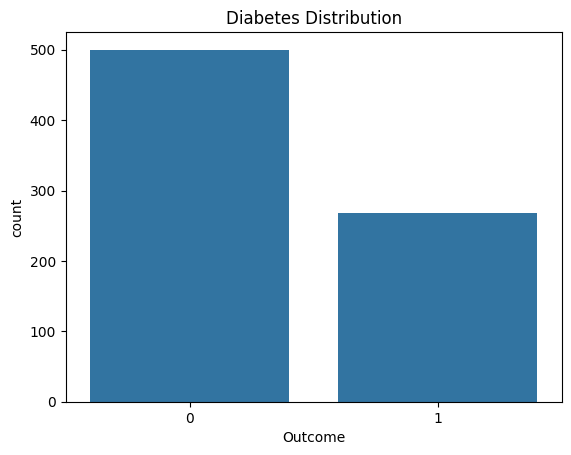

In [7]:
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Distribution")
plt.show()

The dataset is slightly imbalanced, with more non-diabetic cases than diabetic. This may affect model performance, so evaluation metrics like recall and ROC-AUC are important instead of relying only on accuracy.

#### Correlation Heatmap 

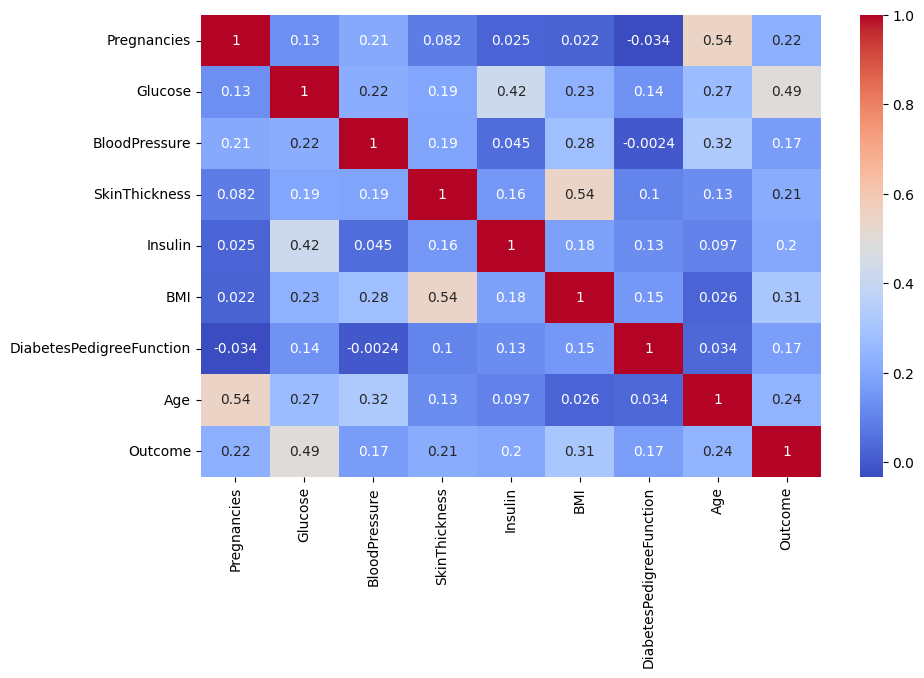

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Glucose shows the highest correlation with diabetes outcome, making it the most important predictor. BMI and Age also have moderate influence. Some features like BMI and SkinThickness are correlated with each other, indicating possible redundancy.

Boxplots (Outlier Detection)

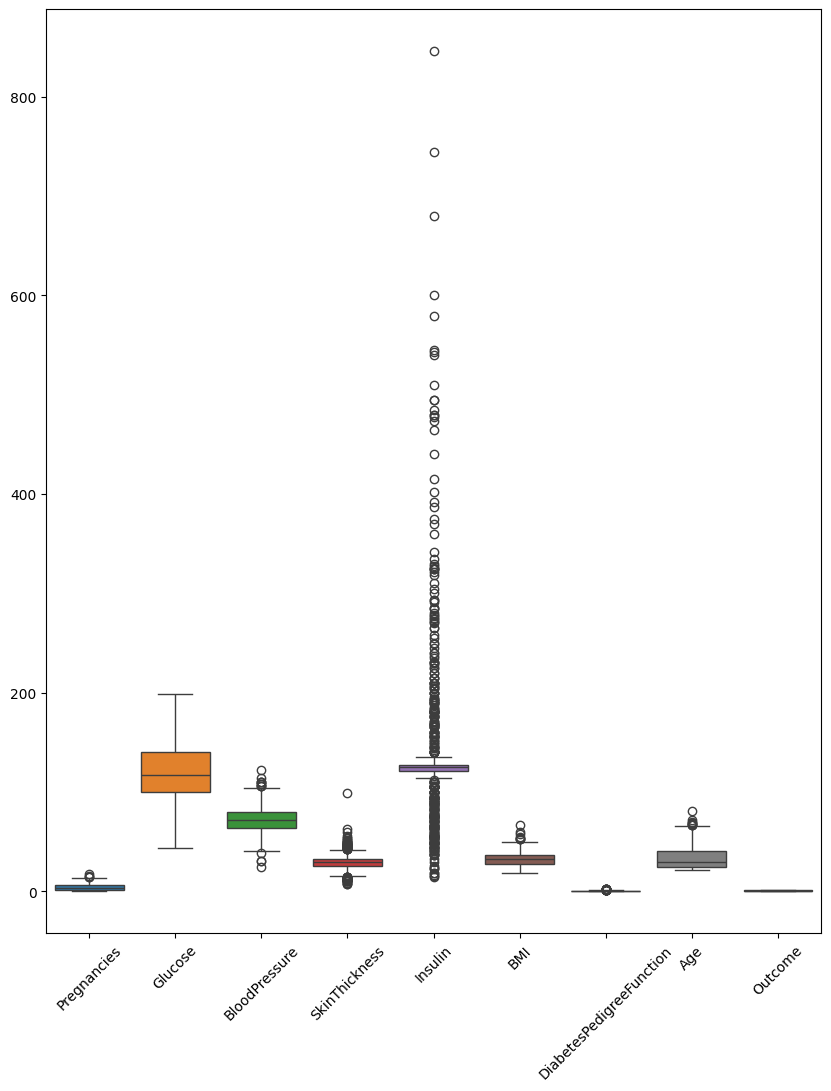

In [11]:
plt.figure(figsize=(10,12))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

Several features, especially Insulin, show extreme outliers. This indicates variability in the data and the need for scaling or transformation before model training.

📈 Distribution Analysis (Histograms)

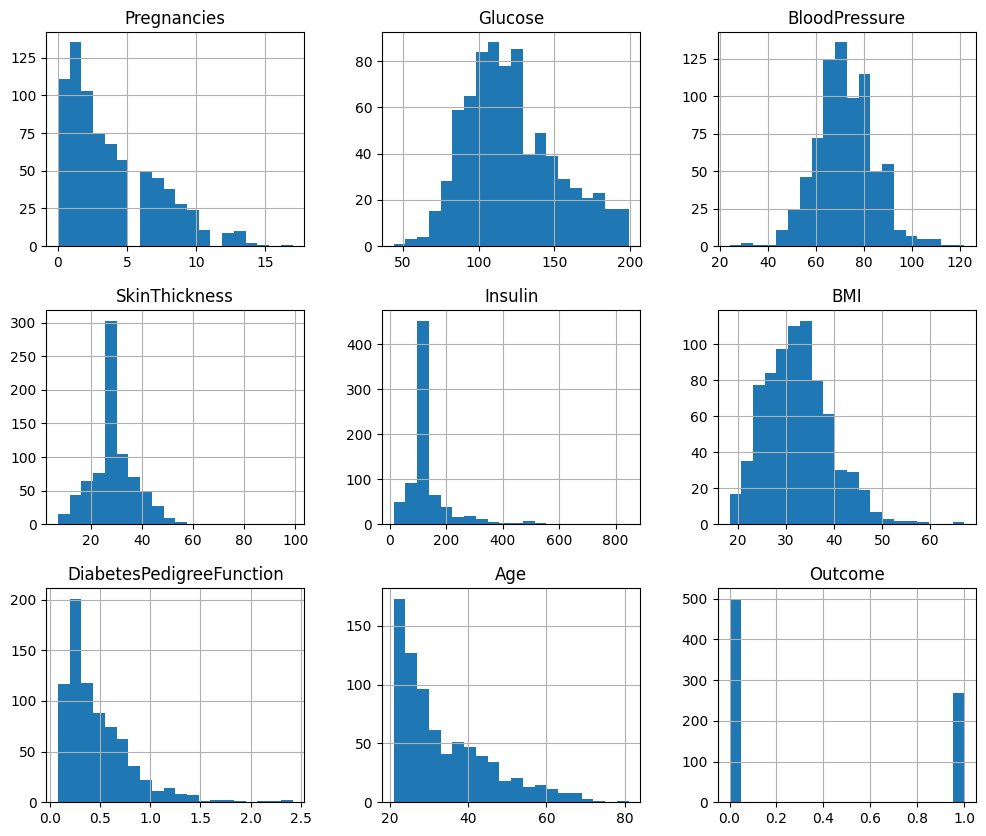

In [12]:
df.hist(figsize=(12,10), bins=20)
plt.show()

Many features such as Insulin and Diabetes Pedigree Function are highly skewed, while others like Glucose and BMI are more normally distributed. Skewed features may require transformation for better model performance.

## Feature vs Target Analysis

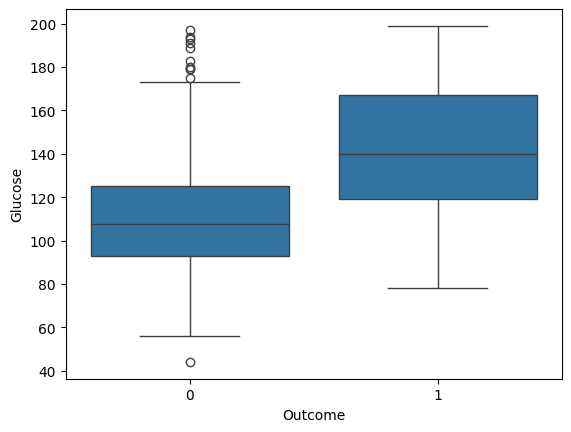

In [15]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.show()

Diabetic patients have significantly higher glucose levels compared to non-diabetic, making glucose the strongest predictor of diabetes.

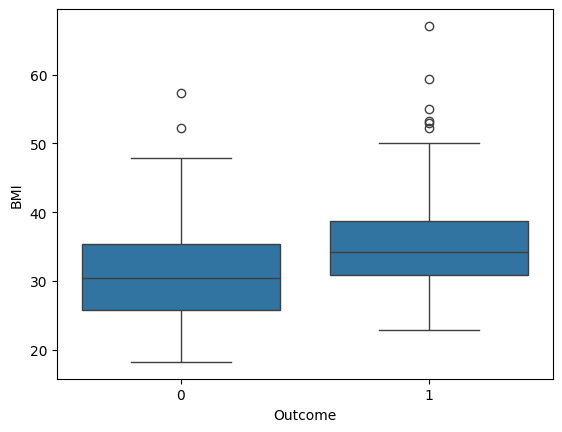

In [16]:
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.show()

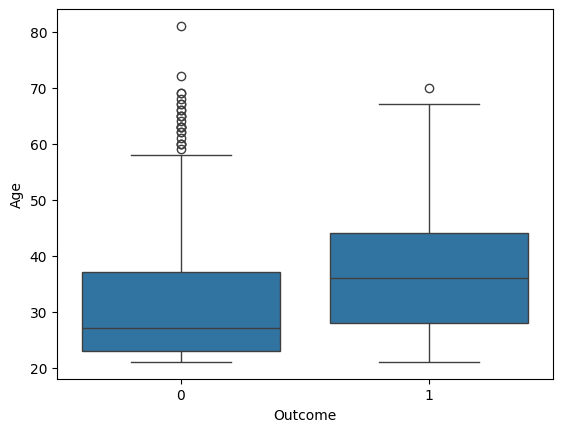

In [17]:
sns.boxplot(x='Outcome', y='Age', data=df)
plt.show()

Diabetic patients tend to be older on average, indicating age is a contributing risk factor.

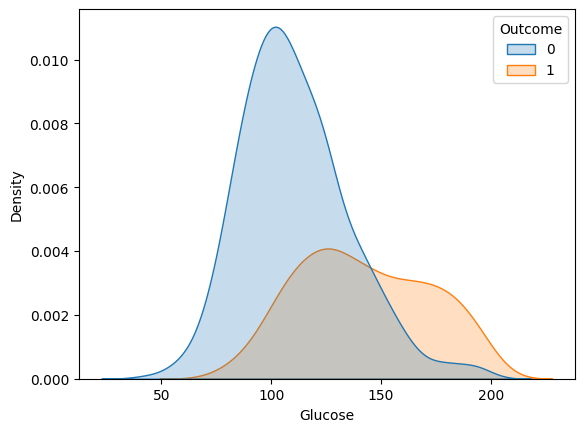

In [18]:
sns.kdeplot(data=df, x='Glucose', hue='Outcome', fill=True)
plt.show()

The glucose distribution for diabetic patients is clearly shifted towards higher values, showing strong separation between diabetic and non-diabetic groups.

## 🧠 Key Insights from EDA

- Glucose is the strongest predictor of diabetes
- BMI and Age have moderate influence
- Dataset contains skewness and outliers
- Some features show multicollinearity

## ⚙️ Feature Engineering

Features were scaled using StandardScaler to ensure uniform contribution to the model.

In [19]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

🤖 6. Model Training & Comparison

In [20]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

# Display results
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.7532
Decision Tree: 0.7013
Random Forest: 0.7727
SVM: 0.7468


In [41]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [22]:
preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.7532467532467533
ROC-AUC: 0.823048668503214
[[77 22]
 [16 39]]
              precision    recall  f1-score   support

           0       0.83      0.78      0.80        99
           1       0.64      0.71      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154



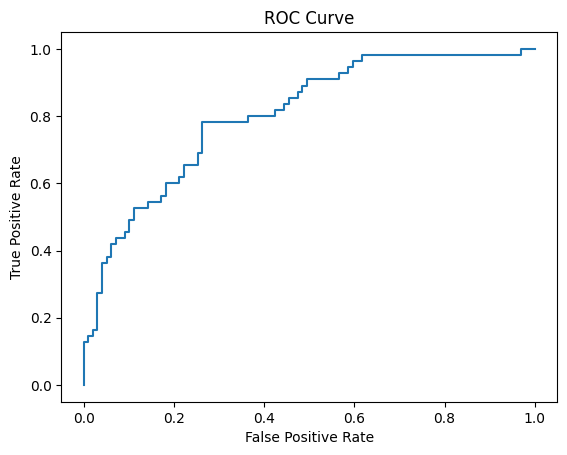

In [40]:
fpr, tpr, _ = roc_curve(y_test, probs)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

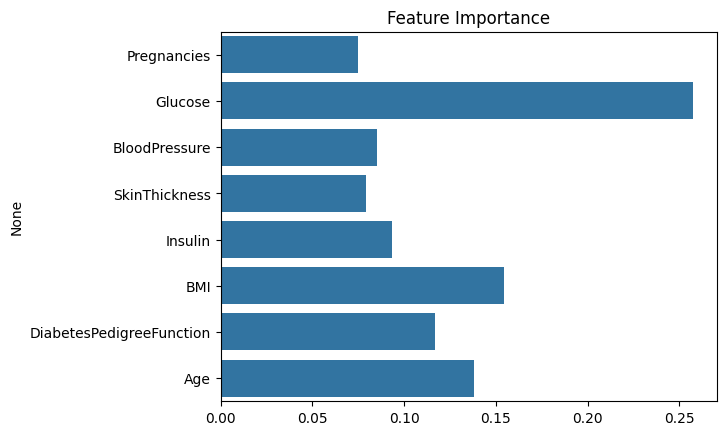

In [23]:
importances = best_model.feature_importances_
features = X.columns

sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

In [24]:
comparison = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, preds)
    roc = roc_auc_score(y_test, probs) if probs is not None else None
    
    comparison.append([name, acc, roc])

pd.DataFrame(comparison, columns=["Model", "Accuracy", "ROC-AUC"])

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.753247,0.822773
1,Decision Tree,0.707792,0.687879
2,Random Forest,0.759740,0.831772
3,SVM,0.746753,NaN


In [25]:
probs = best_model.predict_proba(X_test)[:,1]
custom_preds = (probs > 0.4).astype(int)

In [26]:
comparison = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, preds)
    roc = roc_auc_score(y_test, probs) if probs is not None else None
    
    comparison.append([name, acc, roc])

pd.DataFrame(comparison, columns=["Model", "Accuracy", "ROC-AUC"])

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.753247,0.822773
1,Decision Tree,0.694805,0.677778
2,Random Forest,0.727273,0.821120
3,SVM,0.746753,NaN


In [27]:
import os
import pickle

os.makedirs("models", exist_ok=True)

import pickle
pickle.dump(best_model, open("models/model.pkl", "wb"))
pickle.dump(scaler, open("models/scaler.pkl", "wb"))

In [28]:
print(type(best_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [29]:
df['BMI_Age'] = df['BMI'] * df['Age']
df['Glucose_BMI'] = df['Glucose'] * df['BMI']
df['HOMA_IR'] = (df['Glucose'] * df['Insulin']) / 405

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid = GridSearchCV(
    GradientBoostingClassifier(),
    param_grid,
    cv=5,
    scoring='recall'   # 🔥 KEY CHANGE
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

In [32]:
# 1. Get probability from model
prob = model.predict_proba(X_test)[:, 1]

# 2. Apply threshold
threshold = 0.4
prediction = (prob > threshold).astype(int)

In [33]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Get probabilities
probs = best_model.predict_proba(X_test)[:, 1]

# Set threshold (important)
threshold = 0.4

# Convert to predictions
y_pred = (probs > threshold).astype(int)

# Metrics
print("Threshold:", threshold)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Threshold: 0.4
Accuracy: 0.7402597402597403
Recall: 0.7454545454545455
Precision: 0.6119402985074627
F1 Score: 0.6721311475409836


In [34]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, probs)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8036730945821855


###  Model Selection

Although Random Forest performed well, Gradient Boosting with a custom threshold was selected to improve recall and better detect diabetic cases.

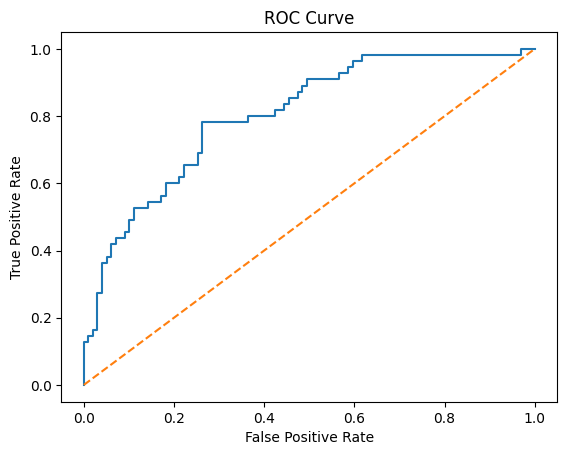

In [37]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [38]:
import os
import pickle

os.makedirs("models", exist_ok=True)

# Save model
pickle.dump(best_model, open("models/model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("models/scaler.pkl", "wb"))

# Save feature names (IMPORTANT)
pickle.dump(X.columns.tolist(), open("models/features.pkl", "wb"))

In [39]:
sample = X_test[0:1]

pred = model.predict(sample)
prob = model.predict_proba(sample)

print(pred, prob)

[1] [[0.39754403 0.60245597]]


## 🌐 Deployment

The final model was deployed using Streamlit, allowing users to input medical parameters and receive real-time predictions.

## 🧠 Conclusion

This project demonstrates that glucose is the most significant factor in diabetes prediction. By combining EDA insights with machine learning models, a reliable prediction system was built and deployed.

The project emphasizes the importance of recall in healthcare applications to minimize missed diagnoses.